# Can a cost-to-go be decomposed? An introduction to anchored ANOVA
- Dinesh Krishnamoorthy (dinesh.krishnamoorthy@ntnu.no)

**The central hypothesis of THINKFAST.** The cost-to-go of an engineered system inherits the coupling structure of its dynamics and constraints. It can therefore be built from a few low-dimensional modules, instead of being learned as one monolithic function.

The natural question that then arises is: **does a cost-to-go even decompose?** Yes. Anchored ANOVA writes *any* multivariable function exactly as a sum of terms of increasing order, each computed from point evaluations of the function alone:

$$
V(x) = V_0 + \sum_{i} V_i(z_i) + \sum_{i<j} V_{ij}(z_i, z_j) + \dots + V_{1\dots m}(z_1,\dots,z_m)
$$

Decomposition itself is therefore not an assumption. The real question, and the hypothesis THINKFAST tests, is how many of these terms are needed: whether the significant ones are few, low-order, and follow the couplings of the system.

In this notebook, I introduce the concept of anchored ANOVA decomposition using a Rosenbrock function to show:
1. How each term is constructed from function evaluations around an anchor point.
2. That the terms reassemble the original function exactly.
3. What is lost when interaction terms are dropped (as in current methods that assume additivity).
4. Why each term can be learned in its own low-dimensional space.

Notebooks 2–4 apply the same decomposition to the cost-to-go of an inventory problem with a shared resource (2), uncertain demand (3) and integer orders (4).

## 1. The Rosenbrock function
For the sake of exposition, we assume the true value function takes the form of a Rosenbrock funciton

$$
V(x_1,x_2)=(1-x_1)^2+100(x_2-x_1^2)^2.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

def rosenbrock(x1, x2):
    """Two-dimensional Rosenbrock function."""
    return (1 - x1)**2 + 100 * (x2 - x1**2)**2

## 2. The Anchor point

The **anchor** is the reference point used to construct the lower-order terms.

We choose the Rosenbrock minimum as the anchor, 

$$
(a_1,a_2)=(1,1).
$$

This would be the same as anchoring at the equilibrium point. In the case of value function decomposition, we would often know the desired equilibroum point, which can be used as the anchor. 

In [2]:
# Anchor point
a1, a2 = 1.0, 1.0
anchor = (a1, a2)

# Plotting domain
x1_min, x1_max = -2.0, 2.0
x2_min, x2_max = -1.0, 3.0

# Number of grid points
N = 200

x1 = np.linspace(x1_min, x1_max, N)
x2 = np.linspace(x2_min, x2_max, N)
X1, X2 = np.meshgrid(x1, x2)

F = rosenbrock(X1, X2)


## 3. Anchored ANOVA decomposition

For two variables, the anchored decomposition has four terms.

### Zeroth order

$$
V_0=V(a_1,a_2).
$$

### First-order $x_1$ contribution

$$
V_1(x_1)=V(x_1,a_2)-V_0.
$$

### First-order $x_2$ contribution

$$
V_2(x_2)=V(a_1,x_2)-V_0.
$$

### Second-order interaction

$$
V_{12}(x_1,x_2)
=V(x_1,x_2)-V(x_1,a_2)-V(a_1,x_2)+V_0.
$$


In [3]:
# Zeroth-order contribution
f0 = rosenbrock(a1, a2)

# First-order contribution from x1
F1 = rosenbrock(X1, a2) - f0

# First-order contribution from x2
F2 = rosenbrock(a1, X2) - f0

# Second-order interaction
F12 = (
    rosenbrock(X1, X2)
    - rosenbrock(X1, a2)
    - rosenbrock(a1, X2)
    + f0
)

## 4. Reconstruct the original function

The decomposition should reproduce the original function:

$$
\hat V=V_0+V_1(x_1)+V_2(x_2)+V_{12}(x_1,x_2).
$$

For this two-variable anchored decomposition, the reconstruction is algebraically exact. 

In [4]:
F_reconstructed = f0 + F1 + F2 + F12

error_matrix = F - F_reconstructed
max_error = np.max(np.abs(error_matrix))
rms_error = np.sqrt(np.mean(error_matrix**2))

print("=" * 45)
print(" Anchored ANOVA decomposition")
print("=" * 45)
print(f"Anchor = [{a1:g}, {a2:g}]")
print(f"f0 = {f0:.6f}")
print()
print(f"Maximum reconstruction error: {max_error:.3e}")
print(f"RMS reconstruction error:     {rms_error:.3e}")


 Anchored ANOVA decomposition
Anchor = [1, 1]
f0 = 0.000000

Maximum reconstruction error: 4.547e-13
RMS reconstruction error:     3.258e-14


### Visualize the four ANOVA components, and the reconstructed function

- $V_0$: baseline value at the anchor.
- $V_1$: effect of changing $x_1$ while $x_2=a_2$.
- $V_2$: effect of changing $x_2$ while $x_1=a_1$.
- $V_{12}$: the additional contribution requiring both variables.

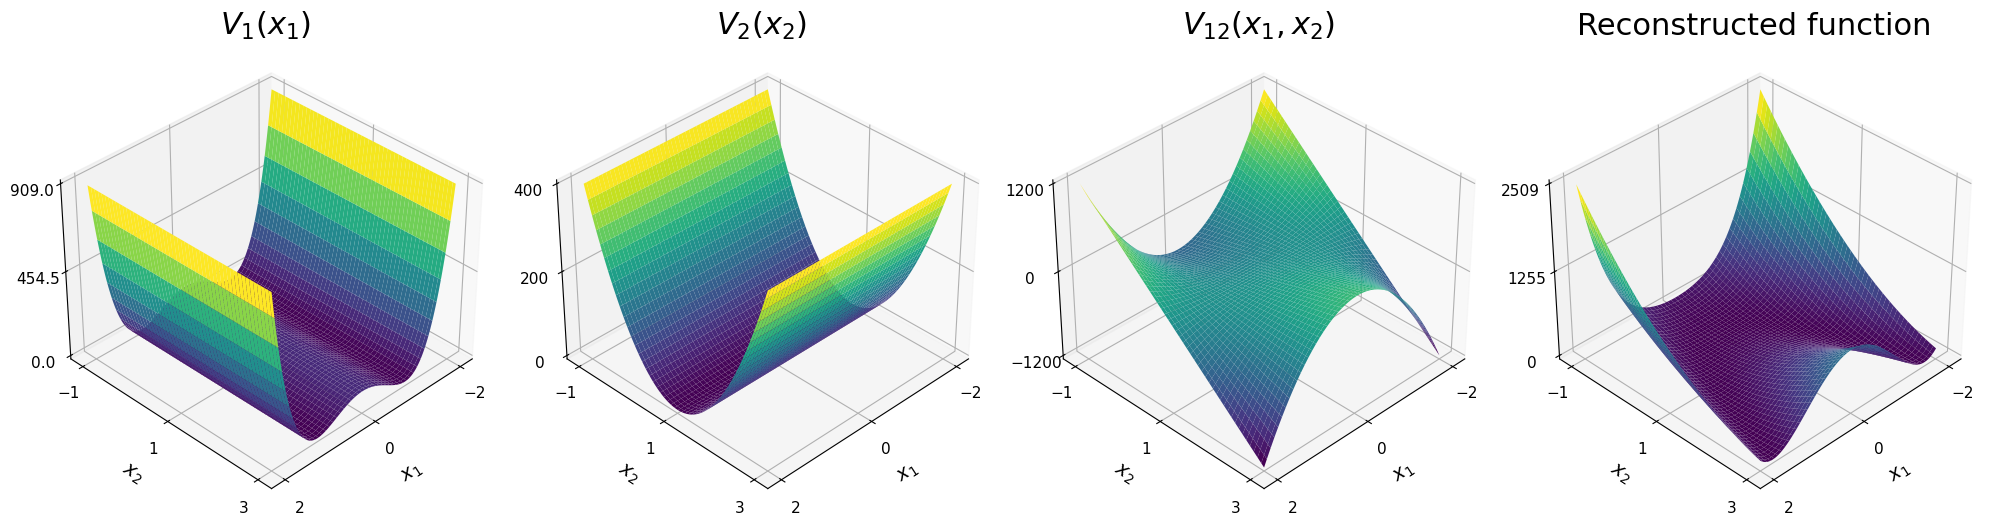

In [5]:
fig = plt.figure(figsize=(20, 5))

components = [
    (F1, r"", r"$V_1(x_1)$"),
    (F2, r"", r"$V_2(x_2)$"),
    (F12, r"", r"$V_{12}(x_1,x_2)$"),
    (
        F_reconstructed,
        r"",
        "Reconstructed function"
    ),
]

# Three ticks for x1 and x2: min, midpoint, max
x1_ticks = [x1_min, (x1_min + x1_max) / 2, x1_max]
x2_ticks = [x2_min, (x2_min + x2_max) / 2, x2_max]

for i, (Z, zlabel, title) in enumerate(components, start=1):

    ax = fig.add_subplot(1, 4, i, projection="3d")

    ax.plot_surface(
        X1,
        X2,
        Z,
        cmap="viridis",
        edgecolor="none",
        linewidth=0,
        antialiased=True
    )

    # ---------------------------------------------------------
    # Axis labels
    # ---------------------------------------------------------
    ax.set_xlabel(r"$x_1$", fontsize=14, labelpad=8)
    ax.set_ylabel(r"$x_2$", fontsize=14, labelpad=8)
    ax.set_zlabel(zlabel, fontsize=14, labelpad=8)

    # ---------------------------------------------------------
    # X and Y ticks: min, midpoint, max
    # ---------------------------------------------------------
    ax.set_xticks(x1_ticks)
    ax.set_yticks(x2_ticks)

    # ---------------------------------------------------------
    # Z ticks: min, midpoint, max for each surface
    # ---------------------------------------------------------
    z_min = np.min(Z)
    z_max = np.max(Z)
    z_mid = (z_min + z_max) / 2

    ax.set_zticks([z_min, z_mid, z_max])

    # Tick label size
    ax.tick_params(axis="both", labelsize=11)

    # ---------------------------------------------------------
    # Bigger subplot title
    # ---------------------------------------------------------
    ax.set_title(
        title,
        fontsize=22,
        pad=12
    )

    # ---------------------------------------------------------
    # Same viewing angle
    # ---------------------------------------------------------
    ax.view_init(
        elev=35,
        azim=45
    )

plt.tight_layout()

fig.savefig(
    "anchored_anova_decomposition.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight"
)

plt.show()

### Original versus reconstructed function

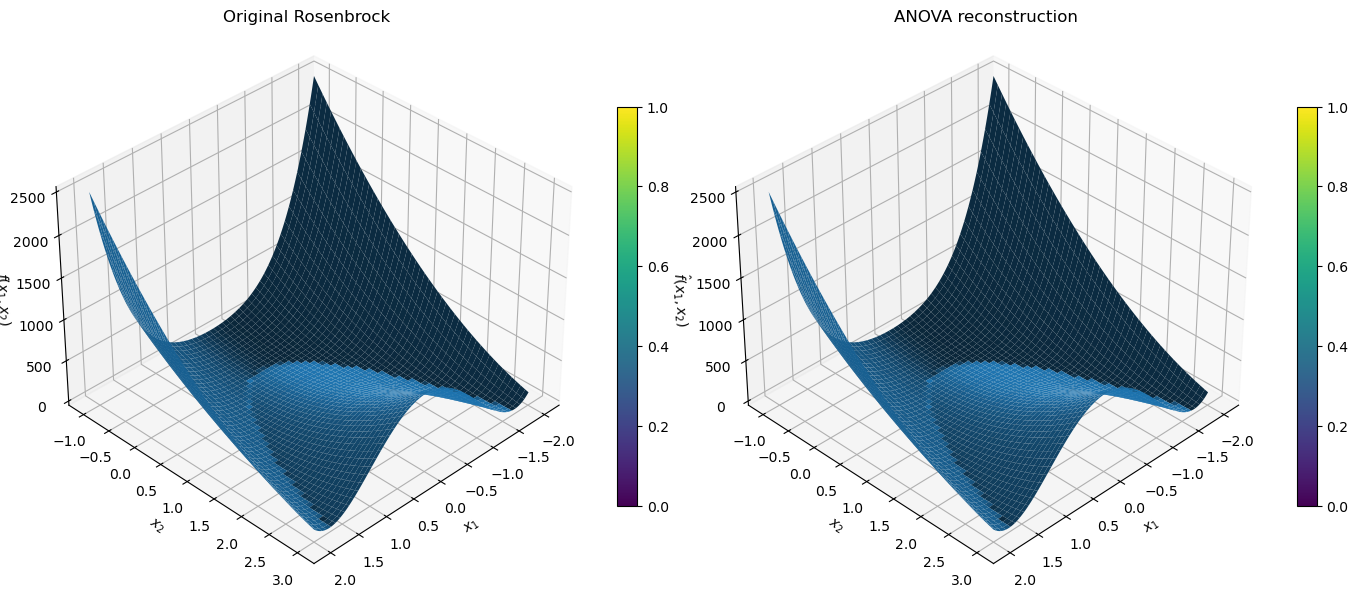

In [6]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf1 = ax1.plot_surface(X1, X2, F, edgecolor="none")
ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_zlabel(r"$f(x_1,x_2)$")
ax1.set_title("Original Rosenbrock")
ax1.view_init(elev=35, azim=45)
fig.colorbar(surf1, ax=ax1, shrink=0.7)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf2 = ax2.plot_surface(X1, X2, F_reconstructed, edgecolor="none")
ax2.set_xlabel(r"$x_1$")
ax2.set_ylabel(r"$x_2$")
ax2.set_zlabel(r"$\hat f(x_1,x_2)$")
ax2.set_title("ANOVA reconstruction")
ax2.view_init(elev=35, azim=45)
fig.colorbar(surf2, ax=ax2, shrink=0.7)

plt.tight_layout()
plt.show()


## 5. First-order ANOVA effects

Although $V_1$ and $V_2$ were displayed as surfaces above, they are actually one-dimensional functions. 

This reduced dimensionality makes it easir to generate data and learn these modules. 

## When can a module be discarded, and when must it be retained?

Every module in the anchored decomposition is defined exactly, but not every module matters. A module can be discarded when its contribution is negligible compared with the modules that are kept, measured over the region of interest, for example by the ratio

$$
\rho_{12} = \frac{\lVert V_{12} \rVert}{\lVert V_1 \rVert + \lVert V_2 \rVert}.
$$

- **If $\rho_{12}$ is small**, $V_{12}$ can be discarded. The function is then approximated by first-order modules alone, each depending on a single variable, so each can be learned separately in one dimension.
- **If $\rho_{12}$ is not small**, $V_{12}$ must be retained. It is the part of the function that exists only because the variables are coupled; discarding it throws away the coupling structure.

**The Rosenbrock function is the second case.** For $f(x_1,x_2) = (a - x_1)^2 + b\,(x_2 - x_1^2)^2$, anchored at $c = (c_1, c_2)$, the interaction module is

$$
V_{12}(x_1, x_2) = -2b\,(x_1^2 - c_1^2)(x_2 - c_2).
$$

It is nonzero whenever $b \neq 0$, because it comes entirely from the coupling term $b\,(x_2 - x_1^2)^2$. With $b = 100$, it is of the same order as the first-order modules (see the ratio computed below), so it must be retained. Dropping it, as additive value decompositions like VDN do by assumption, gives the large error.

**Why this matters beyond two dimensions.** In this two-dimensional example, retaining $V_{12}$ saves nothing, since it is as high-dimensional as $f$ itself. The saving appears in higher dimensions. A function of $m$ variable groups has up to $m(m-1)/2$ pairwise modules, but if only the physically coupled pairs are significant, only those need to be learned, each in its own low-dimensional space. Which modules to retain is therefore decided by measurement, not by assumption. This is the screening step in THINKFAST.


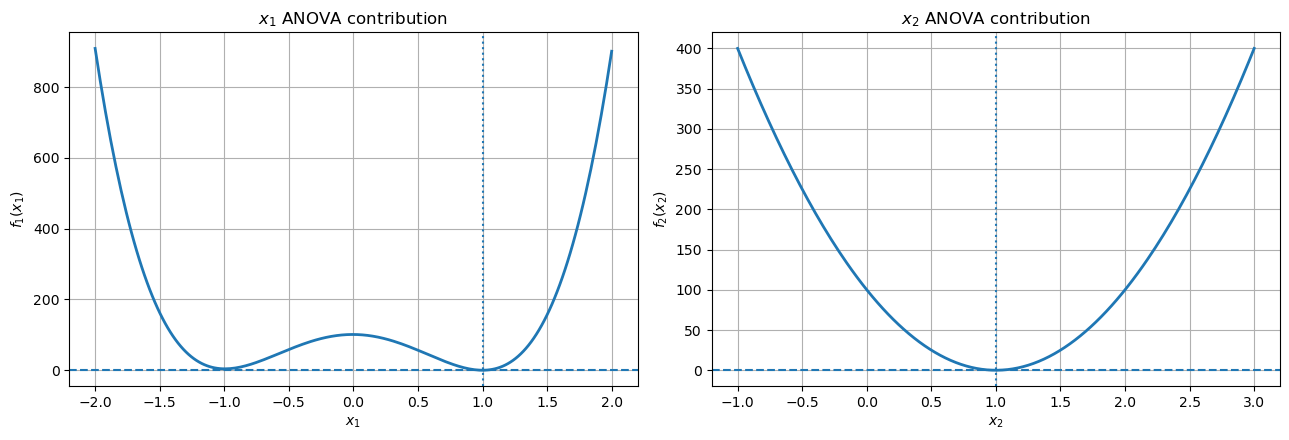

In [7]:
f1_1d = rosenbrock(x1, a2) - f0
f2_1d = rosenbrock(a1, x2) - f0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(x1, f1_1d, linewidth=2)
axes[0].axhline(0, linestyle="--")
axes[0].axvline(a1, linestyle=":")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$f_1(x_1)$")
axes[0].set_title(r"$x_1$ ANOVA contribution")

axes[1].plot(x2, f2_1d, linewidth=2)
axes[1].axhline(0, linestyle="--")
axes[1].axvline(a2, linestyle=":")
axes[1].set_xlabel(r"$x_2$")
axes[1].set_ylabel(r"$f_2(x_2)$")
axes[1].set_title(r"$x_2$ ANOVA contribution")

plt.tight_layout()
plt.show()
